In [15]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import math
import torch.nn.functional as F
import random

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
d = torch.load('/content/drive/MyDrive/data/cifar10.pt', map_location=device)
print(device)

cpu


In [120]:
# -- Helper functions --

# Plot view pairs in grid WIP
def plot_grid(views_list):
  w = h = 32
  fig = plt.figure(figsize=(7, 14))
  columns = len(views_list)
  rows = len(views_list[0])
  for i in range(columns*rows):
      img = views_list[i % columns][i // columns]
      fig.add_subplot(rows, columns, i+1)
      plt.imshow(img.cpu().permute(1,2,0), interpolation='nearest')
      plt.axis('off')
  plt.subplots_adjust(wspace=0, hspace=0)
  plt.show()


# Other helpers made by Claude
# (batch image transforms not supported by torchvision)
LUMA = torch.tensor([0.2989, 0.5870, 0.1140]).view(1, 3, 1, 1)

def _rand(B, lo, hi, device):
    return torch.empty(B, 1, 1, 1, device=device).uniform_(lo, hi)

def _gray(x):                                  # (B,3,H,W) -> (B,3,H,W)
    return (x * LUMA.to(x.device)).sum(1, keepdim=True).expand_as(x)

def brightness_(x, lo=0.6, hi=1.4):
    x.mul_(_rand(x.size(0), lo, hi, x.device))
    return x

def contrast_(x, lo=0.6, hi=1.4):
    f = _rand(x.size(0), lo, hi, x.device)
    mean = _gray(x).mean((1, 2, 3), keepdim=True)   # scalar per image
    x.lerp_(mean, 1 - f)
    return x

def saturation_(x, lo=0.6, hi=1.4):
    f = _rand(x.size(0), lo, hi, x.device)
    x.lerp_(_gray(x), 1 - f)
    return x

def hue_(x, amount=0.1):
    # cheap approximation: rotate the two chroma axes about luma
    f = _rand(x.size(0), -amount, amount, x.device) * 2 * 3.141592653589793
    c, s = torch.cos(f), torch.sin(f)
    g = _gray(x)[:, :1]
    r, gr, b = x[:, 0:1] - g, x[:, 1:2] - g, x[:, 2:3] - g
    x[:, 0:1] = g + c * r - s * b
    x[:, 1:2] = g + gr                              # green anchored
    x[:, 2:3] = g + s * r + c * b
    return x

def hflip_(x, p=0.5):
    m = torch.rand(x.size(0), device=x.device) < p
    x[m] = x[m].flip(-1)
    return x

def greyscale_(x, p=0.2):
    m = torch.rand(x.size(0), device=x.device) < p
    x[m] = _gray(x[m])
    return x

def rrc(x, out=32, scale=(0.4, 1.0), ratio=(3/4, 4/3)):
    B, dev = x.size(0), x.device
    area = torch.empty(B, device=dev).uniform_(*scale)
    logr = torch.empty(B, device=dev).uniform_(math.log(ratio[0]), math.log(ratio[1]))
    ar = torch.exp(logr)
    w = (area * ar).sqrt().clamp(max=1.0)      # crop width as fraction of image
    h = (area / ar).sqrt().clamp(max=1.0)
    cx = torch.rand(B, device=dev) * (1 - w) * 2 - (1 - w)   # centre in [-1,1] coords
    cy = torch.rand(B, device=dev) * (1 - h) * 2 - (1 - h)
    theta = torch.zeros(B, 2, 3, device=dev)
    theta[:, 0, 0], theta[:, 0, 2] = w, cx
    theta[:, 1, 1], theta[:, 1, 2] = h, cy
    grid = F.affine_grid(theta, (B, 3, out, out), align_corners=False)
    return F.grid_sample(x, grid, mode='bilinear', align_corners=False)

In [102]:
class CIFAR_10_GPU(torch.utils.data.Dataset):
  def __init__(self, data, mean=None, std=None):
    super().__init__()
    self.data = data.float() / 255            # [0,1]

    if mean is None:                          # train: compute
      self.mean = self.data.mean((0, 2, 3), keepdim=True)   # (1,3,1,1)
      self.std  = self.data.std((0, 2, 3), keepdim=True)
    else:                                     # test: inherit from train
      self.mean, self.std = mean, std

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.data[idx]

In [112]:
def create_view(x):
  view = rrc(x)
  if random.random() < 0.8:
    brightness_(view)
    contrast_(view)
    saturation_(view)
    hue_(view)
  hflip_(view)
  greyscale_(view)
  return view.clamp_(0, 1)

In [124]:
train_data = CIFAR_10_GPU(d['xtr'])
test_data  = CIFAR_10_GPU(d['xte'], train_data.mean, train_data.std)
train_loader = DataLoader(train_data, batch_size=8, shuffle=True) # TODO: Change batch size and shuffle

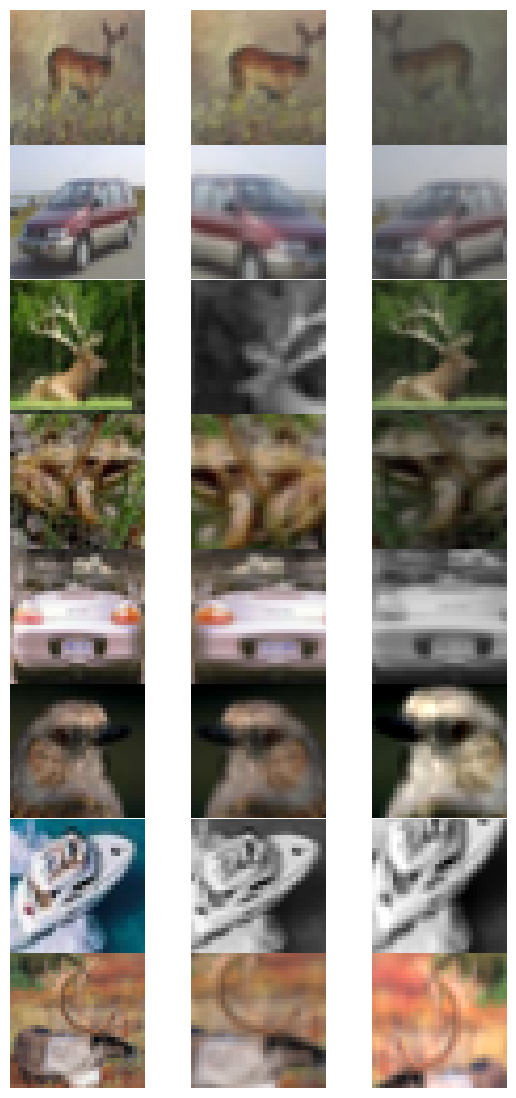

torch.Size([1, 3, 1, 1]) torch.Size([1, 3, 1, 1]) tensor([[[[0.4914]],

         [[0.4822]],

         [[0.4465]]]])


In [136]:
for batch in train_loader:
  # Generate views by (applying transforms)
  views_a = create_view(batch)
  views_b = create_view(batch)

  # Normalise
  views_a = (views_a - train_data.mean) / train_data.std
  views_b = (views_b - train_data.mean) / train_data.std

  # Now un-normalise and view
  views = [batch, views_a * train_data.std + train_data.mean, views_b * train_data.std + train_data.mean]
  plot_grid(views)

  print(train_data.mean.shape, train_data.std.shape, train_data.mean)

  break